In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

In [6]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import pickle

In [7]:
df = pd.read_csv("email_spam_detection.csv")

df.head()

,Email_ID,Sender_Email,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
0,1,,Meeting,NaN,99,-1,7,0,0
1,2,user1@outlook.com,Security Alert,87.0,2,3,8,0,0
2,3,user2@yahoo.com,Win Prize,69.0,0,3,8,0,0
3,4,user3@gmail.com,Invoice,61.0,0,3,8,0,0
4,5,user4@company.com,Meeting,99.0,2,3,5,0,0


In [8]:
df.shape

(7000, 9)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Email_ID           7000 non-null   int64  
 1   Sender_Email       6999 non-null   str    
 2   Subject            7000 non-null   str    
 3   Email_Length       6959 non-null   float64
 4   Num_Links          7000 non-null   int64  
 5   Num_Special_Chars  7000 non-null   int64  
 6   Capital_Words      7000 non-null   int64  
 7   Has_Attachment     7000 non-null   int64  
 8   Spam               7000 non-null   int64  
dtypes: float64(1), int64(6), str(2)
memory usage: 694.4 KB


In [10]:
df.describe()

,Email_ID,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
count,7000.000000,6959.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,3500.500000,110.567898,2.454571,6.636429,12.199714,0.260714,0.305143
std,2020.870275,52.353566,5.319235,6.123388,15.169749,0.439056,0.460501
min,1.000000,20.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,1750.750000,70.000000,0.000000,2.000000,3.000000,0.000000,0.000000
50%,3500.500000,95.000000,1.000000,4.000000,6.000000,0.000000,0.000000
75%,5250.250000,158.000000,3.000000,11.000000,10.250000,1.000000,1.000000
max,7000.000000,265.000000,99.000000,28.000000,59.000000,1.000000,1.000000


In [11]:
df.sample(5)

,Email_ID,Sender_Email,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
5858,5859,user5858@gmail.com,Win Prize,102.0,1,1,0,0,0
5521,5522,user5521@outlook.com,Offer,69.0,1,3,0,0,0
6340,6341,user6340@yahoo.com,Greetings,72.0,1,3,9,1,0
5840,5841,user5840@gmail.com,Meeting,166.0,9,21,45,0,1
229,230,user229@company.com,Win Prize,50.0,1,5,6,1,0


In [12]:
df.isnull().sum()

Email_ID              0
Sender_Email          1
Subject               0
Email_Length         41
Num_Links             0
Num_Special_Chars     0
Capital_Words         0
Has_Attachment        0
Spam                  0
dtype: int64

In [13]:
df.replace("", np.nan, inplace=True)

,Email_ID,Sender_Email,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
0,1,,Meeting,NaN,99,-1,7,0,0
1,2,user1@outlook.com,Security Alert,87.0,2,3,8,0,0
2,3,user2@yahoo.com,Win Prize,69.0,0,3,8,0,0
3,4,user3@gmail.com,Invoice,61.0,0,3,8,0,0
4,5,user4@company.com,Meeting,99.0,2,3,5,0,0
...,...,...,...,...,...,...,...,...,...
6995,6996,user6995@gmail.com,Greetings,93.0,1,2,6,1,0
6996,6997,user6996@yahoo.com,Offer,107.0,0,0,7,0,0
6997,6998,user6997@gmail.com,Account Verification,222.0,7,14,17,0,1
6998,6999,user6998@outlook.com,Win Prize,164.0,6,16,8,1,1


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df.dropna(inplace=True)

In [17]:
df[df["Num_Special_Chars"]==-1]

,Email_ID,Sender_Email,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
311,312,user311@yahoo.com,Security Alert,40.0,4,-1,2,0,0
622,623,user622@company.com,Meeting,184.0,7,-1,6,0,1
933,934,user933@yahoo.com,Meeting,98.0,0,-1,6,0,0
1244,1245,user1244@company.com,Greetings,180.0,5,-1,35,1,1
1555,1556,user1555@gmail.com,Offer,67.0,0,-1,3,0,0
1866,1867,user1866@outlook.com,Invoice,64.0,1,-1,6,0,0
2177,2178,user2177@yahoo.com,Invoice,156.0,3,-1,9,0,1
2488,2489,user2488@company.com,Meeting,88.0,0,-1,3,0,0
2799,2800,user2799@yahoo.com,Meeting,169.0,6,-1,57,0,1
3110,3111,user3110@company.com,Account Verification,86.0,1,-1,3,1,0


In [18]:
df[df["Num_Links"]==99]

,Email_ID,Sender_Email,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
419,420,user419@outlook.com,Project Update,221.0,99,20,19,1,1
838,839,user838@gmail.com,Account Verification,190.0,99,18,21,1,1
1257,1258,user1257@outlook.com,Meeting,75.0,99,7,5,0,0
1676,1677,user1676@gmail.com,Project Update,88.0,99,4,3,1,0
2095,2096,user2095@outlook.com,Offer,169.0,99,19,52,0,1
2514,2515,user2514@company.com,Meeting,52.0,99,2,6,0,0
2933,2934,user2933@yahoo.com,Greetings,23.0,99,0,6,0,0
3352,3353,user3352@gmail.com,Win Prize,120.0,99,6,1,0,0
3771,3772,user3771@outlook.com,Invoice,27.0,99,4,8,0,0
4190,4191,user4190@yahoo.com,Invoice,161.0,99,10,13,0,1


In [19]:
df["Num_Special_Chars"].replace(-1, df["Num_Special_Chars"].median(), inplace=True)

1        3
2        3
3        3
4        3
5        1
        ..
6995     2
6996     0
6997    14
6998    16
6999    17
Name: Num_Special_Chars, Length: 6958, dtype: int64

In [20]:
df["Num_Links"].replace(99, df["Num_Links"].median(), inplace=True)

1       2
2       0
3       0
4       2
5       5
       ..
6995    1
6996    0
6997    7
6998    6
6999    1
Name: Num_Links, Length: 6958, dtype: int64

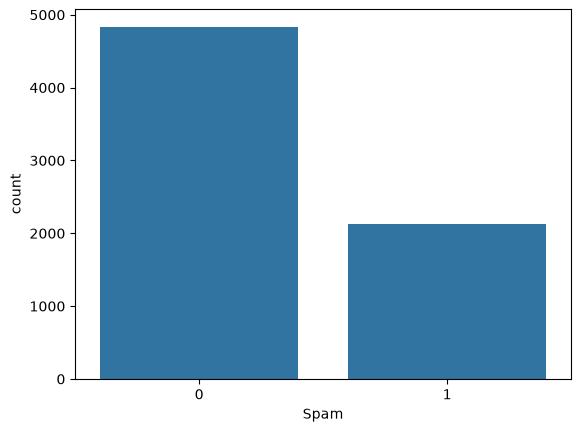

In [21]:
sns.countplot(x="Spam", data=df)
plt.show()

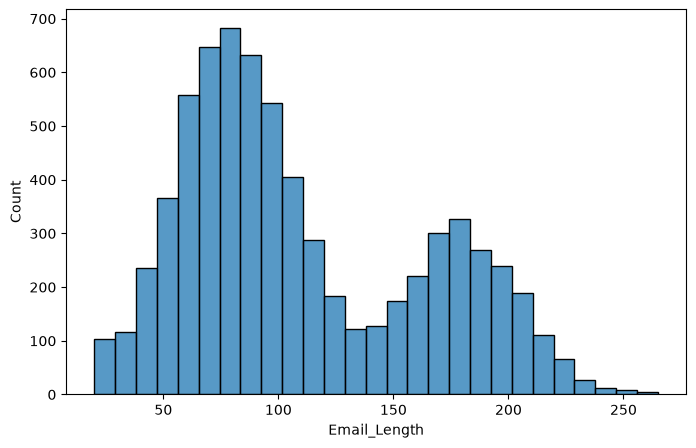

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df["Email_Length"])
plt.show()

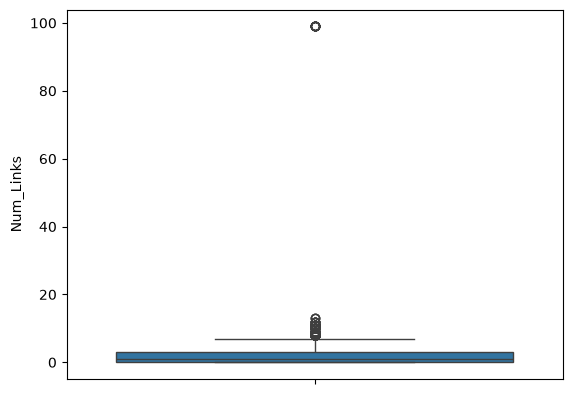

In [23]:
sns.boxplot(df["Num_Links"])
plt.show()

<Axes: xlabel='Num_Special_Chars', ylabel='Count'>

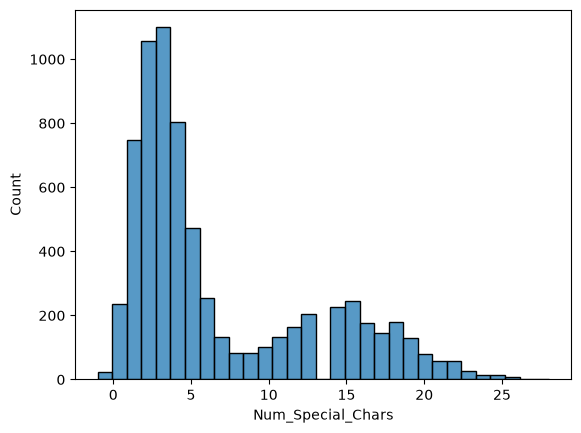

In [24]:
sns.histplot(df["Num_Special_Chars"])

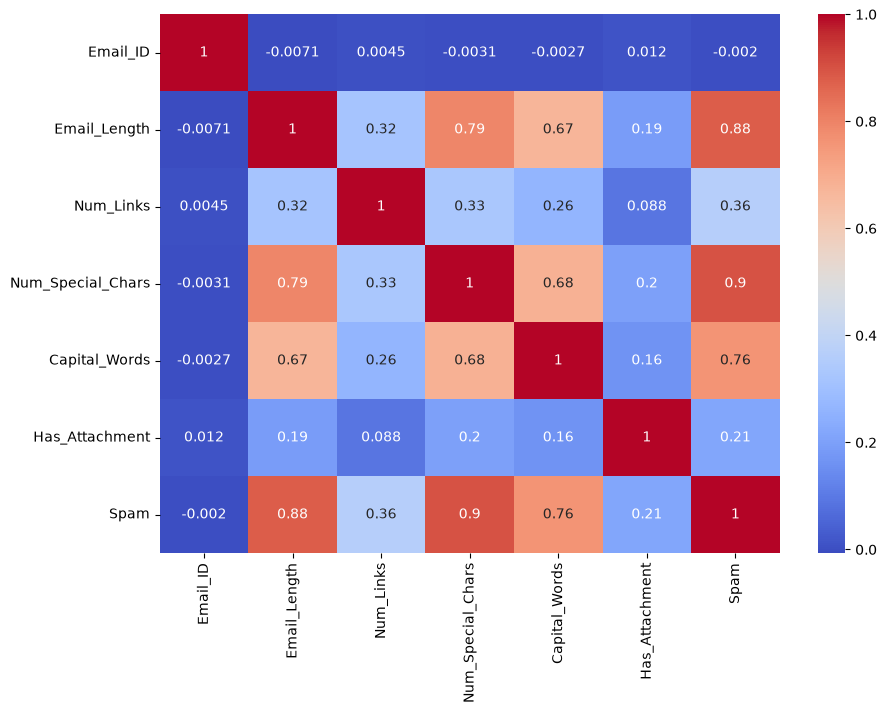

In [25]:
plt.figure(figsize=(10,7))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

In [26]:
encoder = LabelEncoder()

In [27]:
df["Sender_Email"] = encoder.fit_transform(df["Sender_Email"])

In [28]:
df["Subject"] = encoder.fit_transform(df["Subject"])

In [29]:
df["Has_Attachment"] = encoder.fit_transform(df["Has_Attachment"])

In [30]:
X = df.drop("Spam", axis=1)

y = df["Spam"]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
models = {

    "Logistic Regression": LogisticRegression(),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(),

    "KNN": KNeighborsClassifier(),

    "Naive Bayes": GaussianNB(),

    "XGBoost": XGBClassifier()

}

In [33]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, pred)

    precision = precision_score(y_test, pred)

    recall = recall_score(y_test, pred)

    f1 = f1_score(y_test, pred)

    results.append([name,
                    accuracy,
                    precision,
                    recall,
                    f1])

In [34]:
result = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

result.sort_values("Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
5,XGBoost,0.999282,1.000000,0.997590,0.998794
2,Random Forest,0.999282,1.000000,0.997590,0.998794
1,Decision Tree,0.997845,0.995192,0.997590,0.996390
4,Naive Bayes,0.997126,0.992806,0.997590,0.995192
3,KNN,0.971264,0.989556,0.913253,0.949875
0,Logistic Regression,0.943966,0.873614,0.949398,0.909931


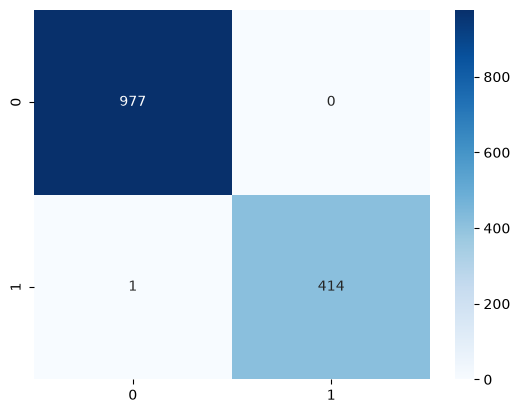

In [35]:
best_model = RandomForestClassifier()

best_model.fit(X_train, y_train)

pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap="Blues")

plt.show()

In [36]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       977
           1       1.00      1.00      1.00       415

    accuracy                           1.00      1392
   macro avg       1.00      1.00      1.00      1392
weighted avg       1.00      1.00      1.00      1392



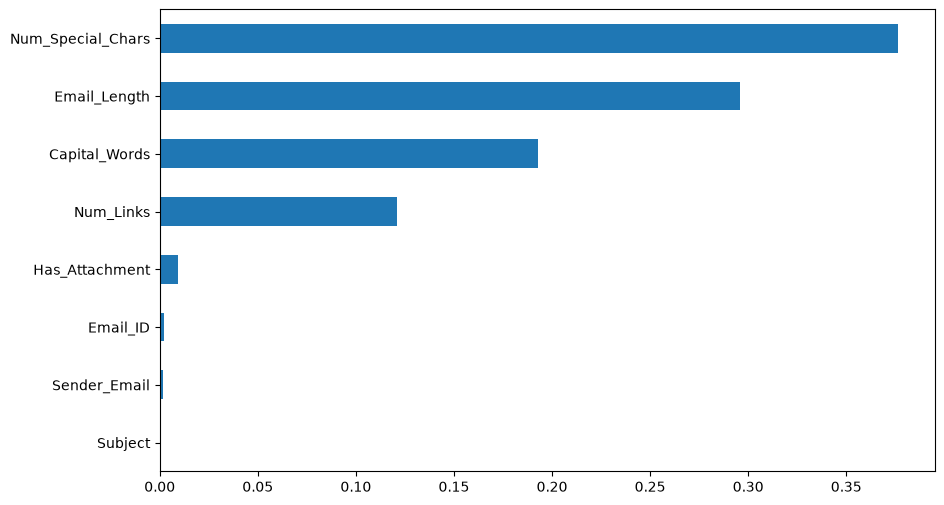

In [37]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.show()

In [38]:
pickle.dump(best_model, open("spam_model.pkl", "wb"))

In [39]:
df.head()

,Email_ID,Sender_Email,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
1,2,1100,6,87.0,2,3,8,0,0
2,3,2200,7,69.0,0,3,8,0,0
3,4,3300,2,61.0,0,3,8,0,0
4,5,4402,3,99.0,2,3,5,0,0
5,6,5501,2,52.0,5,1,8,1,0


In [40]:
df.tail()

,Email_ID,Sender_Email,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
6995,6996,6594,1,93.0,1,2,6,1,0
6996,6997,6595,4,107.0,0,0,7,0,0
6997,6998,6596,0,222.0,7,14,17,0,1
6998,6999,6597,7,164.0,6,16,8,1,1
6999,7000,6598,1,168.0,1,17,55,1,1


In [41]:
df.sample(10)

,Email_ID,Sender_Email,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
3090,3091,2299,1,87.0,1,6,8,0,0
2332,2333,1465,2,75.0,2,1,9,1,0
5290,5291,4719,2,20.0,1,1,7,0,0
4095,4096,3405,3,114.0,0,9,1,0,0
4740,4741,4115,4,79.0,1,4,0,0,0
2052,2053,1158,7,123.0,0,6,2,0,0
2950,2951,2144,2,201.0,3,13,27,0,1
6320,6321,5854,6,141.0,6,9,51,1,1
2029,2030,1132,6,121.0,1,4,1,0,0
54,55,4950,0,25.0,1,3,2,0,0


In [42]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 6958
Columns : 9


In [43]:
df.dtypes

Email_ID               int64
Sender_Email           int64
Subject                int64
Email_Length         float64
Num_Links              int64
Num_Special_Chars      int64
Capital_Words          int64
Has_Attachment         int64
Spam                   int64
dtype: object

In [44]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Email_ID,6958.0,3501.198764,2020.484400,2.0,1752.25,3501.5,5250.75,7000.0
Sender_Email,6958.0,3453.546709,2008.665404,0.0,1714.25,3453.5,5192.75,6932.0
Subject,6958.0,3.504312,2.322044,0.0,1.00,4.0,6.00,7.0
Email_Length,6958.0,110.557919,52.350710,20.0,70.00,95.0,158.00,265.0
Num_Links,6958.0,2.440356,5.203751,0.0,0.00,1.0,3.00,99.0
Num_Special_Chars,6958.0,6.641851,6.128300,-1.0,2.00,4.0,11.00,28.0
Capital_Words,6958.0,12.206381,15.182459,0.0,3.00,6.0,10.00,59.0
Has_Attachment,6958.0,0.260995,0.439209,0.0,0.00,0.0,1.00,1.0
Spam,6958.0,0.305404,0.460611,0.0,0.00,0.0,1.00,1.0


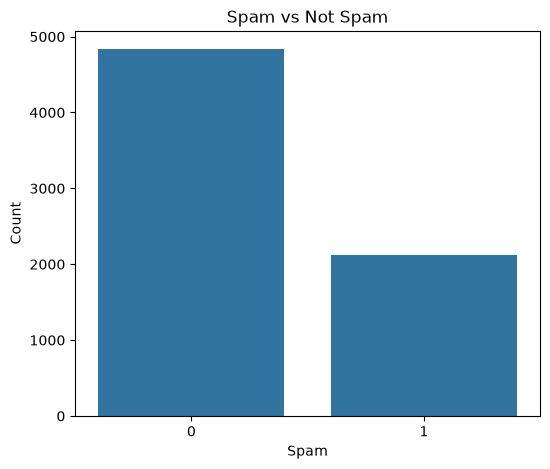

In [45]:
plt.figure(figsize=(6,5))

sns.countplot(x='Spam', data=df)

plt.title("Spam vs Not Spam")
plt.xlabel("Spam")
plt.ylabel("Count")

plt.show()

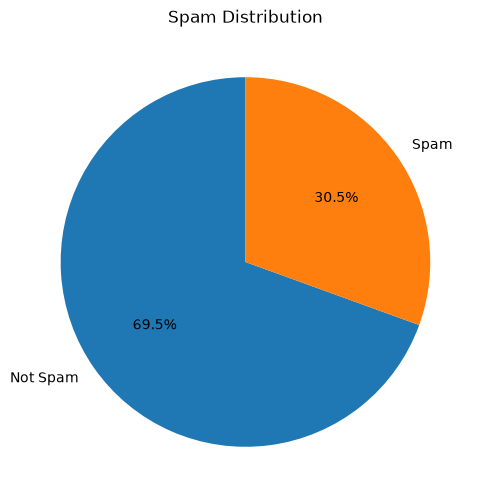

In [46]:
spam_counts = df["Spam"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    spam_counts,
    labels=["Not Spam","Spam"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Spam Distribution")

plt.show()

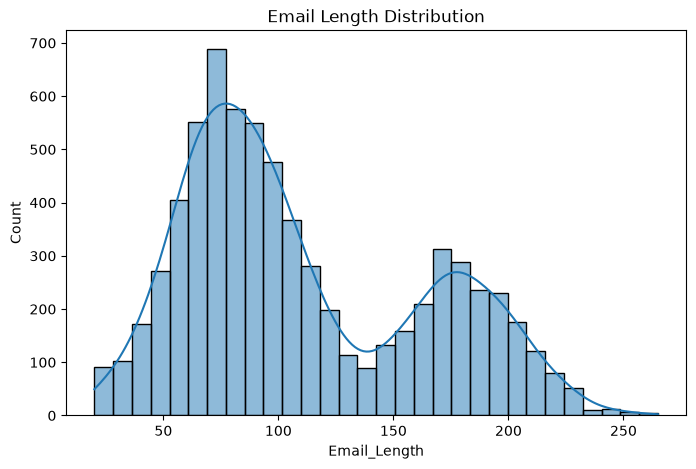

In [47]:
plt.figure(figsize=(8,5))

sns.histplot(df["Email_Length"],
             bins=30,
             kde=True)

plt.title("Email Length Distribution")

plt.show()

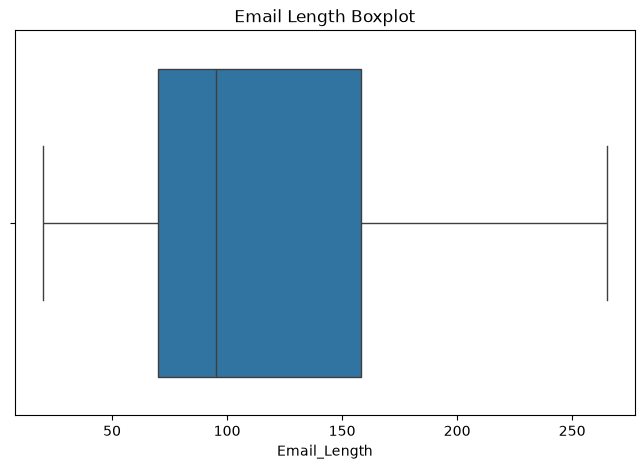

In [48]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Email_Length"])

plt.title("Email Length Boxplot")

plt.show()

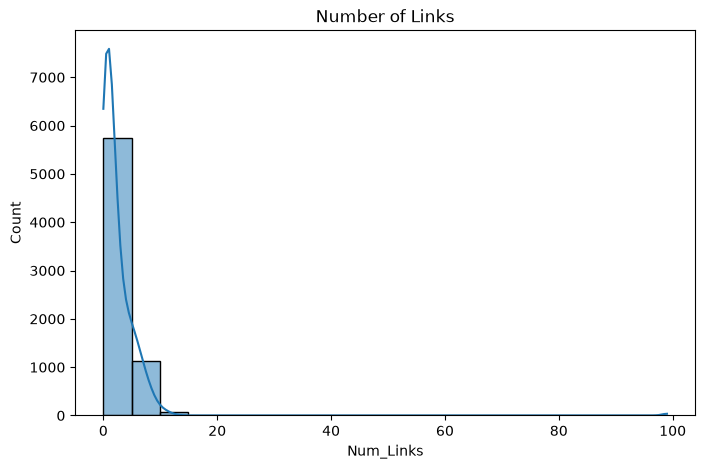

In [49]:
plt.figure(figsize=(8,5))

sns.histplot(df["Num_Links"],
             bins=20,
             kde=True)

plt.title("Number of Links")

plt.show()

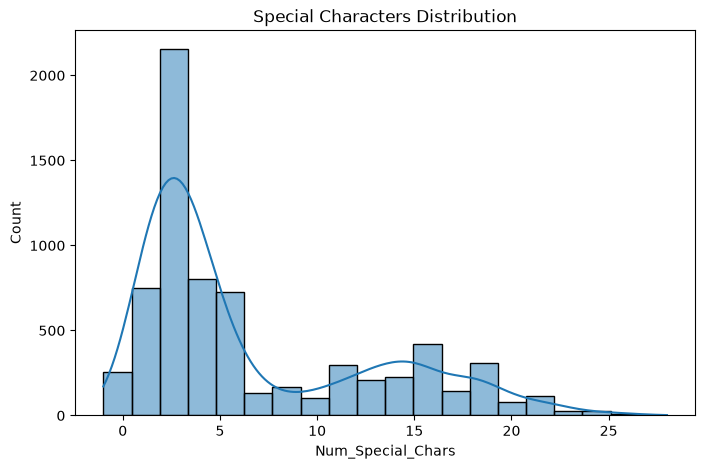

In [50]:
plt.figure(figsize=(8,5))

sns.histplot(df["Num_Special_Chars"],
             bins=20,
             kde=True)

plt.title("Special Characters Distribution")

plt.show()

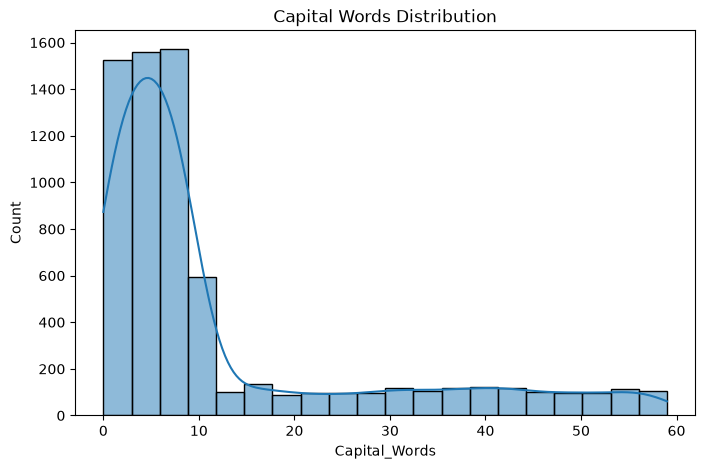

In [51]:
plt.figure(figsize=(8,5))

sns.histplot(df["Capital_Words"],
             bins=20,
             kde=True)

plt.title("Capital Words Distribution")

plt.show()

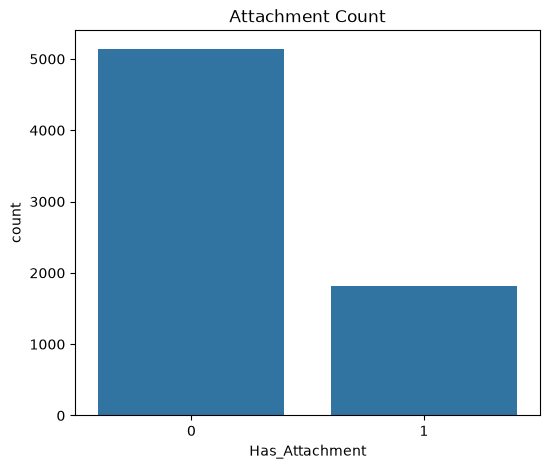

In [52]:
plt.figure(figsize=(6,5))

sns.countplot(x="Has_Attachment", data=df)

plt.title("Attachment Count")

plt.show()

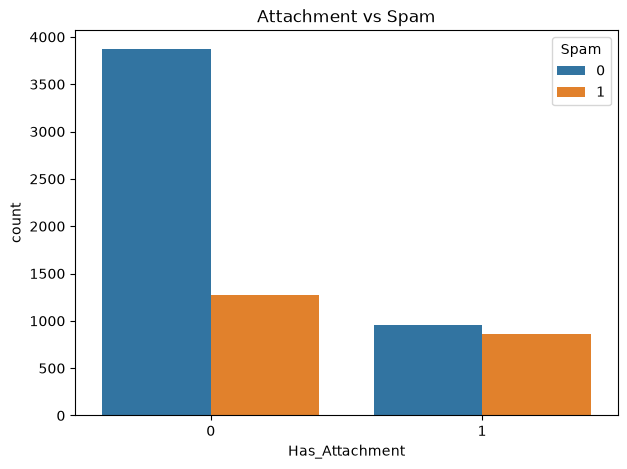

In [53]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Has_Attachment",
    hue="Spam",
    data=df
)

plt.title("Attachment vs Spam")

plt.show()

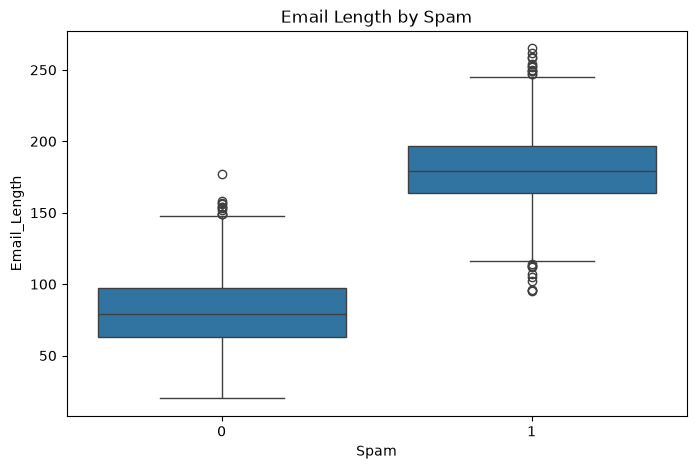

In [54]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Spam",
    y="Email_Length",
    data=df
)

plt.title("Email Length by Spam")

plt.show()

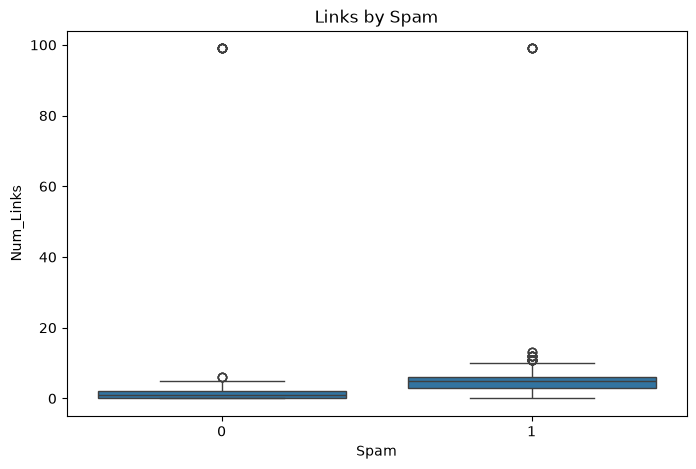

In [55]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Spam",
    y="Num_Links",
    data=df
)

plt.title("Links by Spam")

plt.show()

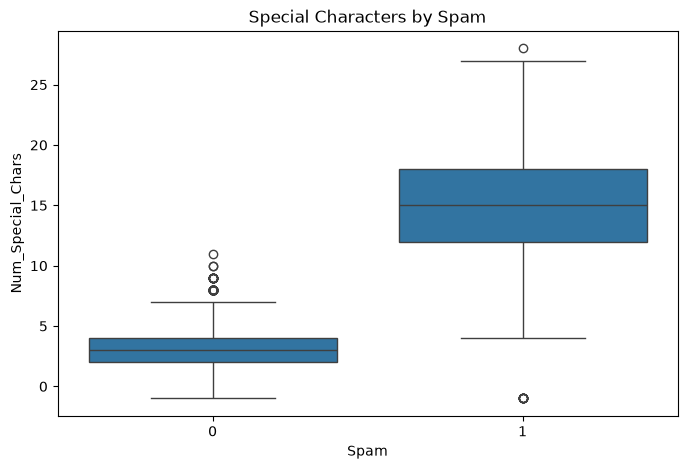

In [56]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Spam",
    y="Num_Special_Chars",
    data=df
)

plt.title("Special Characters by Spam")

plt.show()

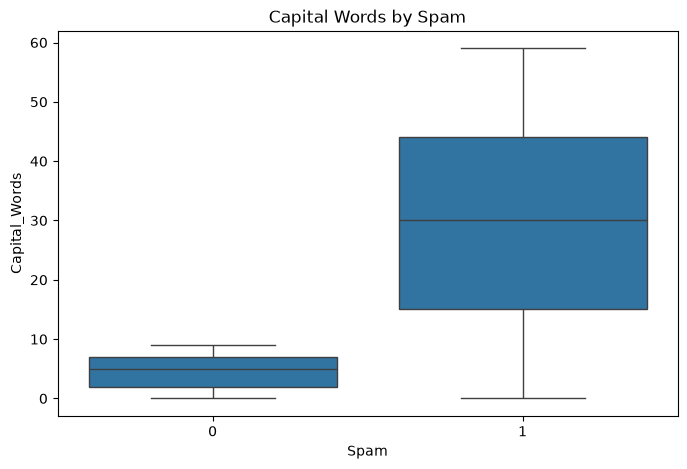

In [57]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Spam",
    y="Capital_Words",
    data=df
)

plt.title("Capital Words by Spam")

plt.show()

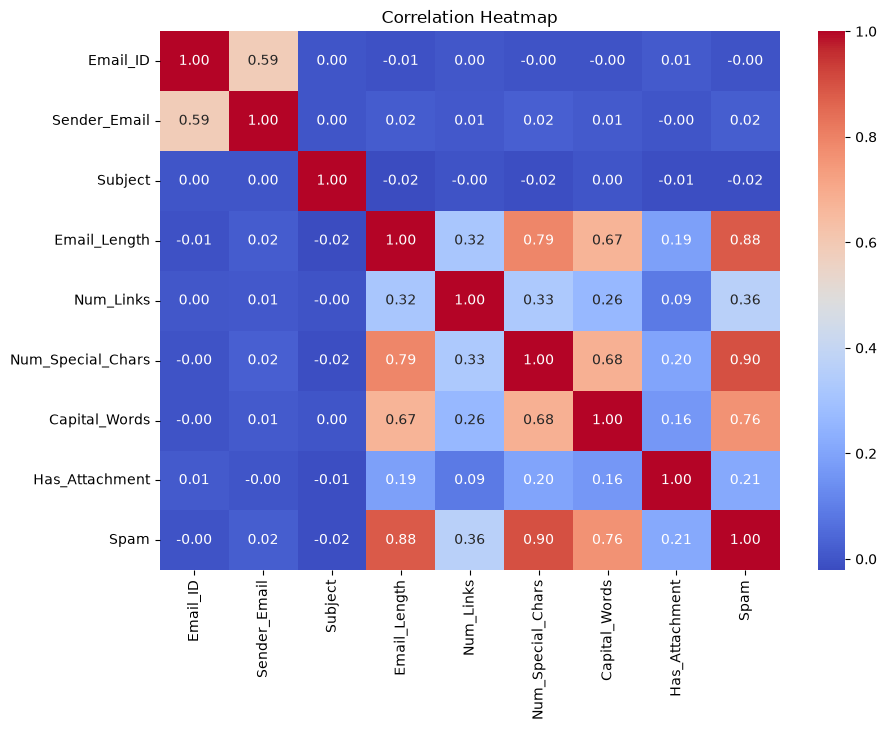

In [58]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

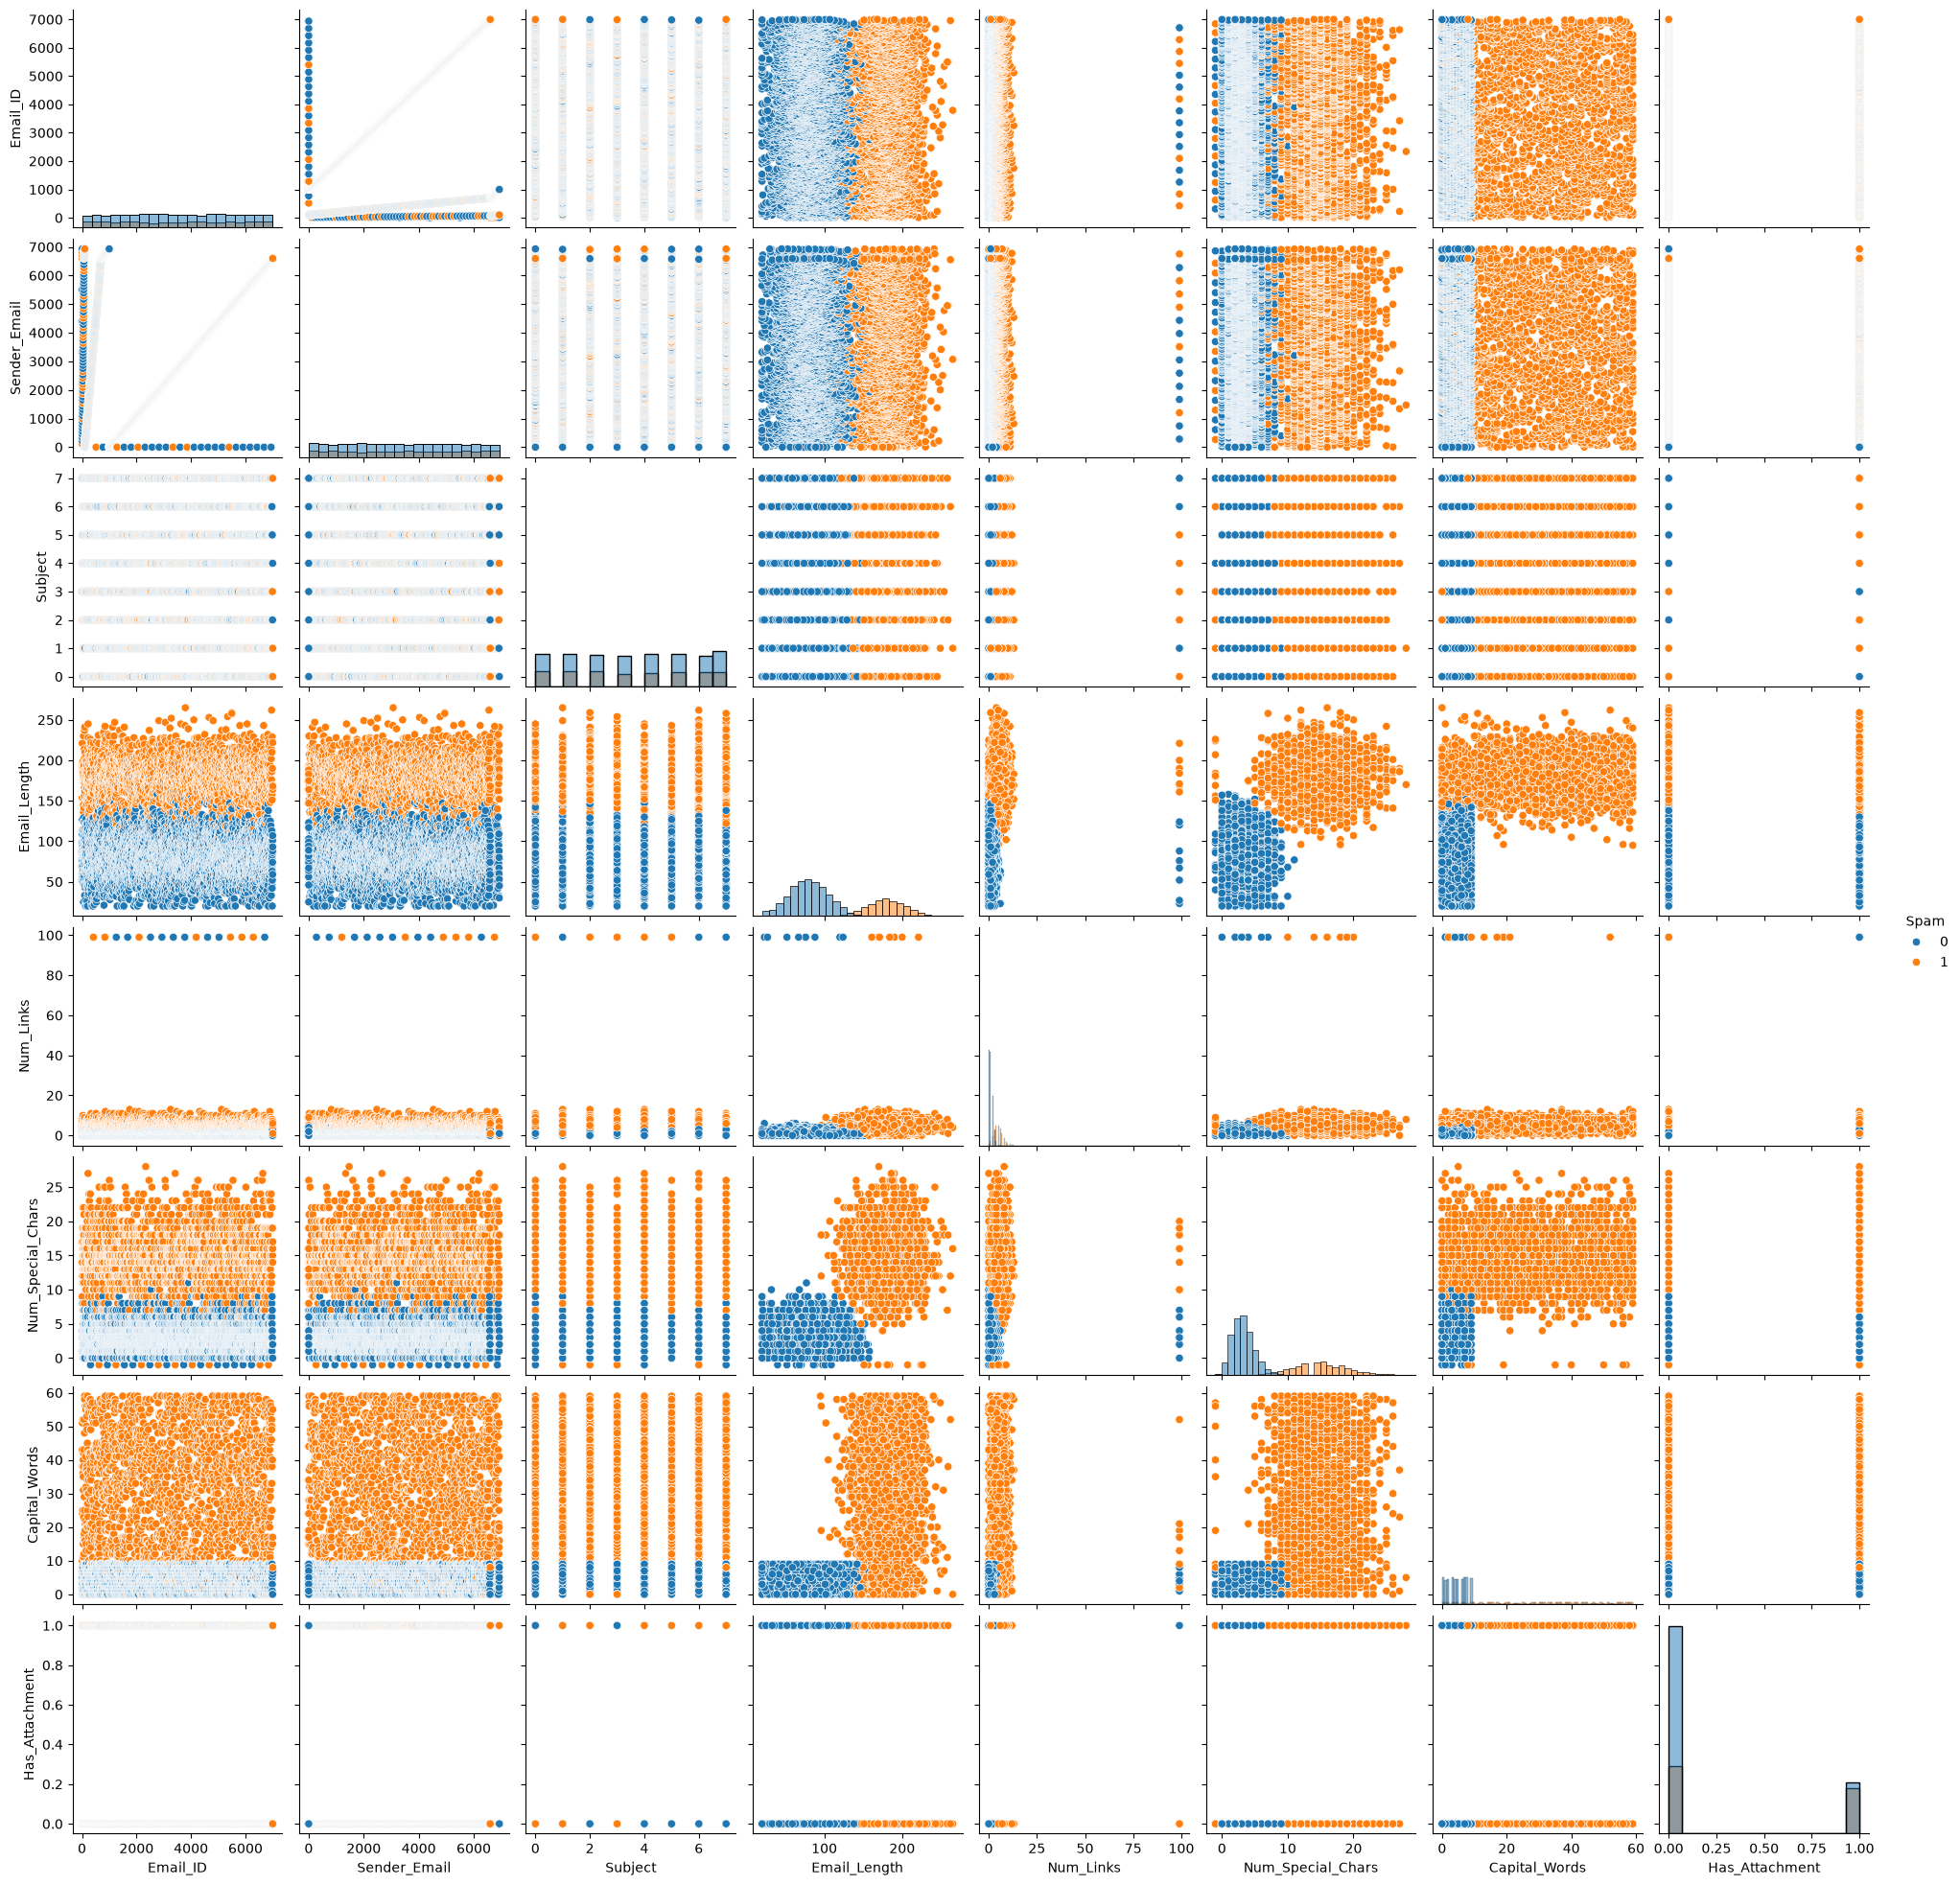

In [59]:
sns.pairplot(
    df,
    hue="Spam",
    diag_kind="hist"
)

plt.show()

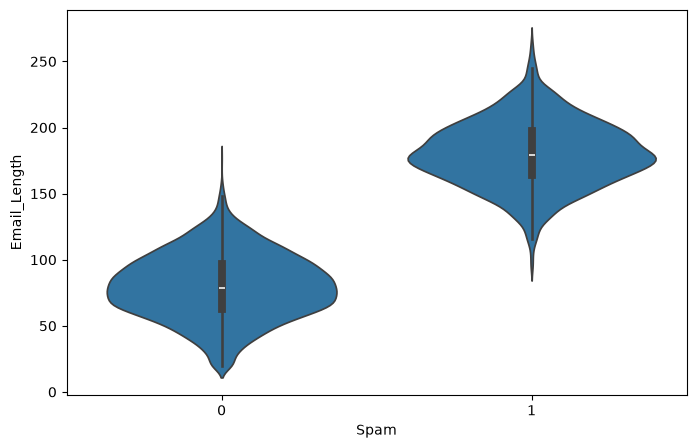

In [60]:
plt.figure(figsize=(8,5))

sns.violinplot(
    x="Spam",
    y="Email_Length",
    data=df
)

plt.show()

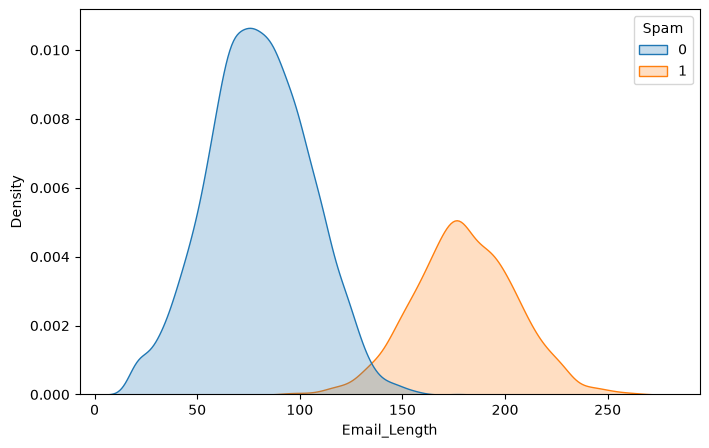

In [61]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x="Email_Length",
    hue="Spam",
    fill=True
)

plt.show()

In [62]:
corr = df.corr(numeric_only=True)

corr.style.background_gradient(cmap="coolwarm")

,Email_ID,Sender_Email,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
Email_ID,1.000000,0.588848,0.002181,-0.007147,0.004522,-0.003067,-0.002745,0.012233,-0.001967
Sender_Email,0.588848,1.000000,0.000081,0.018326,0.009352,0.024087,0.013902,-0.000131,0.019360
Subject,0.002181,0.000081,1.000000,-0.021494,-0.004939,-0.016033,0.001312,-0.013929,-0.016082
Email_Length,-0.007147,0.018326,-0.021494,1.000000,0.316258,0.791513,0.669937,0.187682,0.881942
Num_Links,0.004522,0.009352,-0.004939,0.316258,1.000000,0.329264,0.263254,0.088193,0.363367
Num_Special_Chars,-0.003067,0.024087,-0.016033,0.791513,0.329264,1.000000,0.683797,0.198094,0.900555
Capital_Words,-0.002745,0.013902,0.001312,0.669937,0.263254,0.683797,1.000000,0.162385,0.761975
Has_Attachment,0.012233,-0.000131,-0.013929,0.187682,0.088193,0.198094,0.162385,1.000000,0.214850
Spam,-0.001967,0.019360,-0.016082,0.881942,0.363367,0.900555,0.761975,0.214850,1.000000


In [63]:
df.dtypes

Email_ID               int64
Sender_Email           int64
Subject                int64
Email_Length         float64
Num_Links              int64
Num_Special_Chars      int64
Capital_Words          int64
Has_Attachment         int64
Spam                   int64
dtype: object

In [64]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].unique())


Email_ID
[   2    3    4 ... 6998 6999 7000]

Sender_Email
[1100 2200 3300 ... 6596 6597 6598]

Subject
[6 7 2 3 4 5 1 0]

Email_Length
[ 87.  69.  61.  99.  52. 186. 221. 154.  78. 192. 108. 127.  84.  60.
  95.  75. 113.  76. 198.  56. 114. 183.  83. 180. 191.  50. 185.  68.
  64.  93.  62.  82.  86. 179.  54. 115. 145. 193. 106. 136.  25. 230.
 129. 101.  91.  47. 196. 141. 173. 155. 124. 194.  73.  92. 176. 214.
 203.  46.  98.  57. 156. 237. 166. 116. 112.  33.  72. 241. 162. 102.
  80. 210.  43. 175.  90.  20. 174. 125.  88.  65.  85. 188. 172.  27.
  81. 204. 121. 105. 182.  66. 197. 128. 181.  79. 200.  74.  49.  94.
 118. 165. 109.  48.  67. 147. 189. 152. 122. 199. 184.  77.  26. 110.
 153. 178.  70. 150.  41. 177. 215.  63. 190. 169. 245.  34. 107. 228.
  44. 195. 135. 205.  36.  51. 168. 164. 140. 151. 137. 146. 211. 132.
  96. 100. 142. 206.  89. 126. 139. 167. 119. 217. 226. 207.  59.  40.
 117. 222.  58. 201.  45.  37. 160.  24. 163. 103. 202. 161.  55.  30.
 216. 148. 

In [65]:
from sklearn.preprocessing import LabelEncoder

le_sender = LabelEncoder()

df["Sender_Email"] = le_sender.fit_transform(df["Sender_Email"])

In [66]:
le_subject = LabelEncoder()

df["Subject"] = le_subject.fit_transform(df["Subject"])

In [67]:
df["Has_Attachment"] = df["Has_Attachment"].map({
    "Yes":1,
    "No":0
})

In [68]:
df["Spam"] = df["Spam"].map({
    "Spam":1,
    "Not Spam":0
})

In [69]:
df.head()

,Email_ID,Sender_Email,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
1,2,1100,6,87.0,2,3,8,NaN,NaN
2,3,2200,7,69.0,0,3,8,NaN,NaN
3,4,3300,2,61.0,0,3,8,NaN,NaN
4,5,4402,3,99.0,2,3,5,NaN,NaN
5,6,5501,2,52.0,5,1,8,NaN,NaN


In [70]:
df.info()

<class 'pandas.DataFrame'>
Index: 6958 entries, 1 to 6999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Email_ID           6958 non-null   int64  
 1   Sender_Email       6958 non-null   int64  
 2   Subject            6958 non-null   int64  
 3   Email_Length       6958 non-null   float64
 4   Num_Links          6958 non-null   int64  
 5   Num_Special_Chars  6958 non-null   int64  
 6   Capital_Words      6958 non-null   int64  
 7   Has_Attachment     0 non-null      float64
 8   Spam               0 non-null      float64
dtypes: float64(3), int64(6)
memory usage: 543.6 KB


In [71]:
X = df.drop("Spam", axis=1)

y = df["Spam"]

In [72]:
print(X.shape)
print(y.shape)

(6958, 8)
(6958,)


In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

ValueError: Input y contains NaN.

In [ ]:
df["Spam"].isnull().sum()

In [ ]:
df[df["Spam"].isnull()]

In [ ]:
print(df["Spam"].unique())

In [74]:
df = pd.read_csv("cleaned_email_spam.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'cleaned_email_spam.csv'

In [75]:
df = pd.read_csv("email_spam_detection.csv")

In [76]:
print(df["Spam"].unique())

[0 1]


In [79]:
print(df["Spam"].unique())
print(df["Spam"].isnull().sum())

[0 1]
0


In [80]:
df["Spam"] = df["Spam"].map({
    "Spam":1,
    "Not Spam":0
})

In [81]:
df = pd.read_csv("email_spam_detection.csv")
print(df["Spam"].unique())

[0 1]


In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

ValueError: Input y contains NaN.

In [83]:
import pandas as pd

df = pd.read_csv("email_spam_detection.csv")

In [84]:
print(df["Spam"].unique())
print(df["Spam"].value_counts(dropna=False))
print(df["Spam"].isnull().sum())

[0 1]
Spam
0    4864
1    2136
Name: count, dtype: int64
0


In [85]:
X = df.drop("Spam", axis=1)
y = df["Spam"]

print(X.shape)
print(y.shape)

print(X.dtypes)

(7000, 8)
(7000,)
Email_ID               int64
Sender_Email             str
Subject                  str
Email_Length         float64
Num_Links              int64
Num_Special_Chars      int64
Capital_Words          int64
Has_Attachment         int64
dtype: object


In [86]:
X.isnull().sum()

Email_ID              0
Sender_Email          1
Subject               0
Email_Length         41
Num_Links             0
Num_Special_Chars     0
Capital_Words         0
Has_Attachment        0
dtype: int64

In [87]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

In [88]:
cat_cols = X.select_dtypes(include="object").columns

for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

In [89]:
X.isnull().sum()

Email_ID             0
Sender_Email         0
Subject              0
Email_Length         0
Num_Links            0
Num_Special_Chars    0
Capital_Words        0
Has_Attachment       0
dtype: int64

In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [91]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

In [92]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [93]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    )
}

In [94]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

print("Training Completed!")

ValueError: could not convert string to float: 'user3907@company.com'

In [95]:
print(X_train.dtypes)

Email_ID               int64
Sender_Email             str
Subject                  str
Email_Length         float64
Num_Links              int64
Num_Special_Chars      int64
Capital_Words          int64
Has_Attachment         int64
dtype: object


In [96]:
X_train.select_dtypes(include="object").columns

Index(['Sender_Email', 'Subject'], dtype='str')

In [97]:
print(X_train.dtypes)

print("\nObject Columns:")
print(X_train.select_dtypes(include="object").columns)

print("\nFirst 5 rows:")
print(X_train.head())

Email_ID               int64
Sender_Email             str
Subject                  str
Email_Length         float64
Num_Links              int64
Num_Special_Chars      int64
Capital_Words          int64
Has_Attachment         int64
dtype: object

Object Columns:
Index(['Sender_Email', 'Subject'], dtype='str')

First 5 rows:
      Email_ID          Sender_Email               Subject  Email_Length  \
3907      3908  user3907@company.com        Project Update         106.0   
2278      2279    user2278@yahoo.com        Security Alert          83.0   
4926      4927  user4926@company.com        Project Update         169.0   
3625      3626    user3625@gmail.com  Account Verification         162.0   
1920      1921    user1920@yahoo.com             Win Prize          62.0   

      Num_Links  Num_Special_Chars  Capital_Words  Has_Attachment  
3907          1                  2              4               1  
2278          0                  3              8               1  
4926         

In [98]:
from sklearn.preprocessing import LabelEncoder

le_sender = LabelEncoder()
X["Sender_Email"] = le_sender.fit_transform(X["Sender_Email"])

In [99]:
le_subject = LabelEncoder()
X["Subject"] = le_subject.fit_transform(X["Subject"])

In [100]:
X["Has_Attachment"] = X["Has_Attachment"].map({
    "Yes": 1,
    "No": 0
})

In [101]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [102]:
print(X_train.dtypes)
print(X_train.select_dtypes(include="object").columns)

Email_ID               int64
Sender_Email           int64
Subject                int64
Email_Length         float64
Num_Links              int64
Num_Special_Chars      int64
Capital_Words          int64
Has_Attachment       float64
dtype: object
Index([], dtype='str')


In [103]:
print(X_train.isnull().sum())

Email_ID                0
Sender_Email            0
Subject                 0
Email_Length            0
Num_Links               0
Num_Special_Chars       0
Capital_Words           0
Has_Attachment       5600
dtype: int64


In [104]:
print(y_train.isnull().sum())

0


In [105]:
import numpy as np

print(np.isinf(X_train).sum())

Email_ID             0
Sender_Email         0
Subject              0
Email_Length         0
Num_Links            0
Num_Special_Chars    0
Capital_Words        0
Has_Attachment       0
dtype: int64


In [106]:
print(X_train.shape)
print(y_train.shape)

(5600, 8)
(5600,)


In [107]:
X = df.drop(["Spam", "Email_ID"], axis=1)

In [108]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [109]:
X_train.isnull().sum()

Sender_Email          1
Subject               0
Email_Length         38
Num_Links             0
Num_Special_Chars     0
Capital_Words         0
Has_Attachment        0
dtype: int64

In [110]:
y_train.isnull().sum()

np.int64(0)

In [111]:
# Numerical columns
num_cols = ["Email_Length", "Num_Links", "Num_Special_Chars", "Capital_Words"]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [112]:
df["Sender_Email"] = df["Sender_Email"].fillna(df["Sender_Email"].mode()[0])

In [113]:
df["Sender_Email"] = df["Sender_Email"].fillna("Unknown")

In [114]:
X = df.drop(["Spam", "Email_ID"], axis=1)
y = df["Spam"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [115]:
X_train.isnull().sum()

Sender_Email         0
Subject              0
Email_Length         0
Num_Links            0
Num_Special_Chars    0
Capital_Words        0
Has_Attachment       0
dtype: int64

In [116]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

In [117]:
num_cols = ["Email_Length", "Num_Links", "Num_Special_Chars", "Capital_Words"]
cat_cols = ["Sender_Email", "Subject", "Has_Attachment"]

df[num_cols] = num_imputer.fit_transform(df[num_cols])
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [118]:
X = df.drop(["Spam", "Email_ID"], axis=1)

In [119]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

KeyError: 'Accuracy'

In [120]:
print(results)

[]


In [121]:
results_df = pd.DataFrame(results)

print(results_df)
print(results_df.columns)

Empty DataFrame
Columns: []
Index: []
RangeIndex(start=0, stop=0, step=1)


In [122]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

print("Training Completed!")

ValueError: could not convert string to float: 'user3907@company.com'

In [123]:
print(X_train["Sender_Email"].head())
print(type(X_train["Sender_Email"].iloc[0]))

3907    user3907@company.com
2278      user2278@yahoo.com
4926    user4926@company.com
3625      user3625@gmail.com
1920      user1920@yahoo.com
Name: Sender_Email, dtype: str
<class 'str'>


In [124]:
from sklearn.preprocessing import LabelEncoder

sender_encoder = LabelEncoder()
subject_encoder = LabelEncoder()
attachment_encoder = LabelEncoder()

In [125]:
df["Sender_Email"] = sender_encoder.fit_transform(df["Sender_Email"].astype(str))

df["Subject"] = subject_encoder.fit_transform(df["Subject"].astype(str))

df["Has_Attachment"] = attachment_encoder.fit_transform(df["Has_Attachment"].astype(str))

In [126]:
X = df.drop(["Email_ID", "Spam"], axis=1)

y = df["Spam"]

In [127]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [128]:
print(X_train.dtypes)
print(X_train.head())

Sender_Email           int64
Subject                int64
Email_Length         float64
Num_Links            float64
Num_Special_Chars    float64
Capital_Words        float64
Has_Attachment         int64
dtype: object
      Sender_Email  Subject  Email_Length  Num_Links  Num_Special_Chars  \
3907          3216        5         106.0        1.0                2.0   
2278          1414        6          83.0        0.0                3.0   
4926          4344        5         169.0        6.0                9.0   
3625          2904        0         162.0        5.0               12.0   
1920          1018        7          62.0        2.0                6.0   

      Capital_Words  Has_Attachment  
3907            4.0               1  
2278            8.0               1  
4926            9.0               1  
3625           41.0               1  
1920            0.0               0  


In [129]:
X = df.drop(["Email_ID", "Sender_Email", "Spam"], axis=1)

In [130]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

KeyError: 'Accuracy'

In [131]:
print(results)

[]


In [132]:
print(X_train.head())
print(X_train.dtypes)

      Sender_Email  Subject  Email_Length  Num_Links  Num_Special_Chars  \
3907          3216        5         106.0        1.0                2.0   
2278          1414        6          83.0        0.0                3.0   
4926          4344        5         169.0        6.0                9.0   
3625          2904        0         162.0        5.0               12.0   
1920          1018        7          62.0        2.0                6.0   

      Capital_Words  Has_Attachment  
3907            4.0               1  
2278            8.0               1  
4926            9.0               1  
3625           41.0               1  
1920            0.0               0  
Sender_Email           int64
Subject                int64
Email_Length         float64
Num_Links            float64
Num_Special_Chars    float64
Capital_Words        float64
Has_Attachment         int64
dtype: object


In [133]:
print(X_train.select_dtypes(include="object").columns)

Index([], dtype='str')


In [134]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred = lr.predict(X_test)

from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, pred))

0.9985714285714286


In [135]:
results = []

for name, model in models.items():
    try:
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1 Score": f1_score(y_test, y_pred)
        })

        print(f"✅ {name} trained successfully")

    except Exception as e:
        print(f"❌ {name} failed")
        print(e)

✅ Logistic Regression trained successfully
✅ Decision Tree trained successfully
✅ Random Forest trained successfully
✅ KNN trained successfully
✅ Naive Bayes trained successfully
✅ XGBoost trained successfully


In [136]:
print(results)

[{'Model': 'Logistic Regression', 'Accuracy': 0.9985714285714286, 'Precision': 0.9976580796252927, 'Recall': 0.9976580796252927, 'F1 Score': 0.9976580796252927}, {'Model': 'Decision Tree', 'Accuracy': 0.9978571428571429, 'Precision': 0.9930232558139535, 'Recall': 1.0, 'F1 Score': 0.9964994165694282}, {'Model': 'Random Forest', 'Accuracy': 0.9992857142857143, 'Precision': 0.9976635514018691, 'Recall': 1.0, 'F1 Score': 0.9988304093567252}, {'Model': 'KNN', 'Accuracy': 0.9864285714285714, 'Precision': 0.9927536231884058, 'Recall': 0.9625292740046838, 'F1 Score': 0.9774078478002378}, {'Model': 'Naive Bayes', 'Accuracy': 0.9985714285714286, 'Precision': 0.9976580796252927, 'Recall': 0.9976580796252927, 'F1 Score': 0.9976580796252927}, {'Model': 'XGBoost', 'Accuracy': 0.9992857142857143, 'Precision': 0.9976635514018691, 'Recall': 1.0, 'F1 Score': 0.9988304093567252}]


In [137]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.999286,0.997664,1.000000,0.998830
1,Random Forest,0.999286,0.997664,1.000000,0.998830
2,Naive Bayes,0.998571,0.997658,0.997658,0.997658
3,Logistic Regression,0.998571,0.997658,0.997658,0.997658
4,Decision Tree,0.997857,0.993023,1.000000,0.996499
5,KNN,0.986429,0.992754,0.962529,0.977408


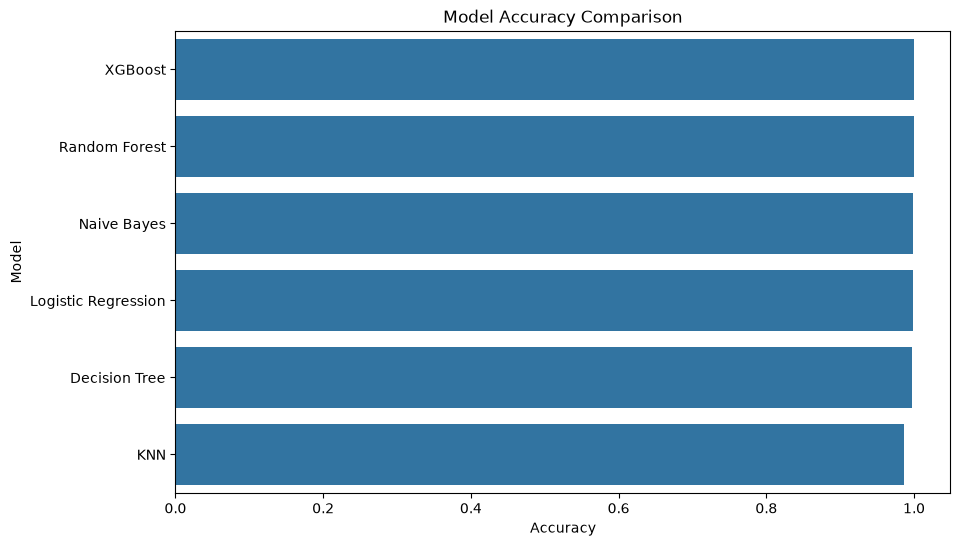

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.show()

In [139]:
from sklearn.ensemble import RandomForestClassifier

best_model = RandomForestClassifier(
    random_state=42
)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

In [140]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       973
           1       1.00      1.00      1.00       427

    accuracy                           1.00      1400
   macro avg       1.00      1.00      1.00      1400
weighted avg       1.00      1.00      1.00      1400



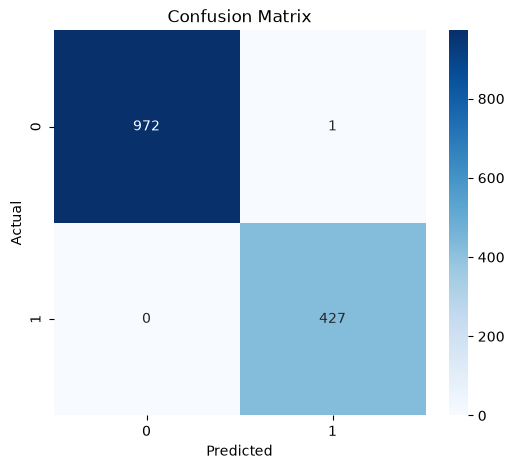

In [141]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

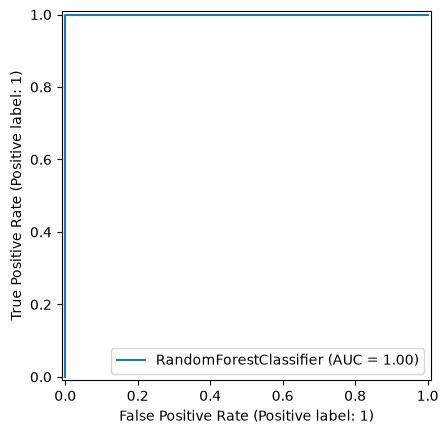

In [142]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.show()

In [143]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=importance.values,
    y=importance.index
)

plt.title("Feature Importance")

plt.show()

ValueError: Length of values (7) does not match length of index (6)

In [144]:
print(len(best_model.feature_importances_))
print(len(X.columns))

print(best_model.feature_importances_)
print(X.columns)

7
6
[0.00148034 0.00079091 0.31623131 0.06478672 0.3695485  0.23794679
 0.00921542]
Index(['Subject', 'Email_Length', 'Num_Links', 'Num_Special_Chars',
       'Capital_Words', 'Has_Attachment'],
      dtype='str')


In [145]:
print(X_train.columns)

Index(['Sender_Email', 'Subject', 'Email_Length', 'Num_Links',
       'Num_Special_Chars', 'Capital_Words', 'Has_Attachment'],
      dtype='str')


In [146]:
print(X.columns)

Index(['Subject', 'Email_Length', 'Num_Links', 'Num_Special_Chars',
       'Capital_Words', 'Has_Attachment'],
      dtype='str')


In [147]:
from sklearn.ensemble import RandomForestClassifier

best_model = RandomForestClassifier(random_state=42)

best_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

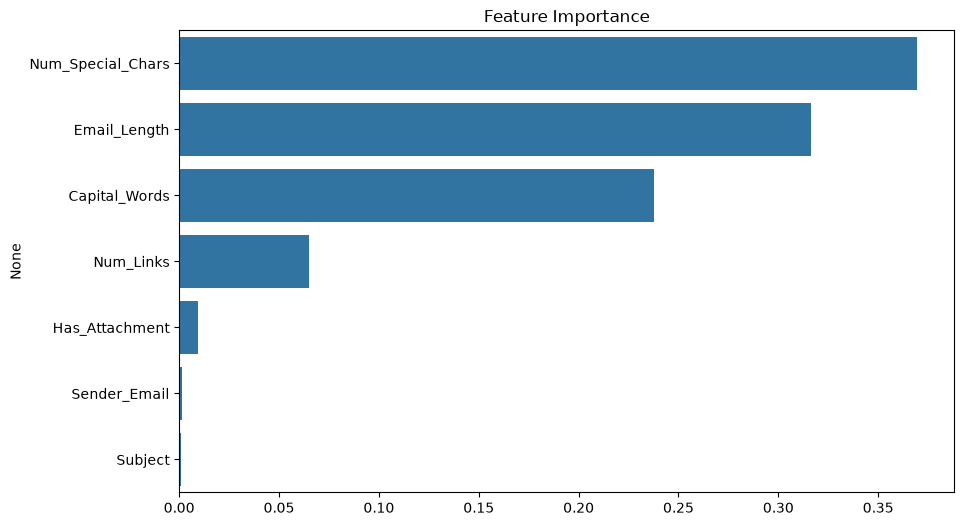

In [148]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns   # Use X_train.columns, not X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=importance.values,
    y=importance.index
)

plt.title("Feature Importance")
plt.show()

In [149]:
print(X_train.columns)
print(X.columns)
print(len(best_model.feature_importances_))

Index(['Sender_Email', 'Subject', 'Email_Length', 'Num_Links',
       'Num_Special_Chars', 'Capital_Words', 'Has_Attachment'],
      dtype='str')
Index(['Subject', 'Email_Length', 'Num_Links', 'Num_Special_Chars',
       'Capital_Words', 'Has_Attachment'],
      dtype='str')
7


In [150]:
X = df.drop(["Email_ID", "Sender_Email", "Spam"], axis=1)
y = df["Spam"]

In [151]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [152]:
from sklearn.ensemble import RandomForestClassifier

best_model = RandomForestClassifier(random_state=42)

best_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

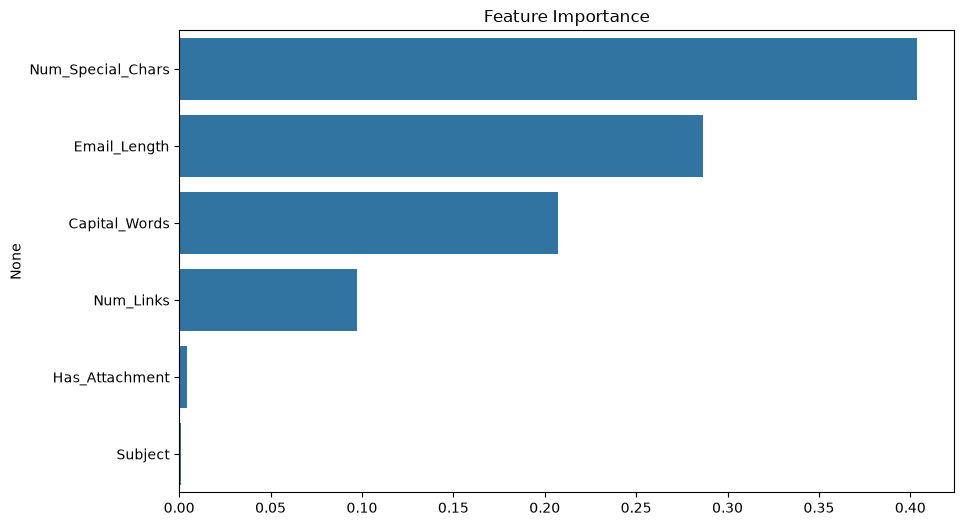

In [153]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=importance.values,
    y=importance.index
)

plt.title("Feature Importance")

plt.show()

In [154]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
)

In [155]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
0.9992857142857143


In [156]:
best_model = grid.best_estimator_

In [157]:
import pickle

pickle.dump(best_model, open("spam_model.pkl", "wb"))

In [158]:
import pickle

# Load model
loaded_model = pickle.load(open("spam_model.pkl", "rb"))

# Test on one sample
sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)

print("Prediction:", prediction[0])
print("Actual:", y_test.iloc[0])

Prediction: 0
Actual: 0


In [159]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = loaded_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       973
           1       1.00      1.00      1.00       427

    accuracy                           1.00      1400
   macro avg       1.00      1.00      1.00      1400
weighted avg       1.00      1.00      1.00      1400



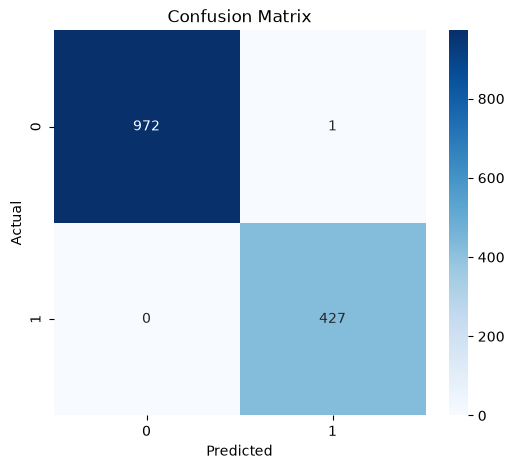

In [160]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

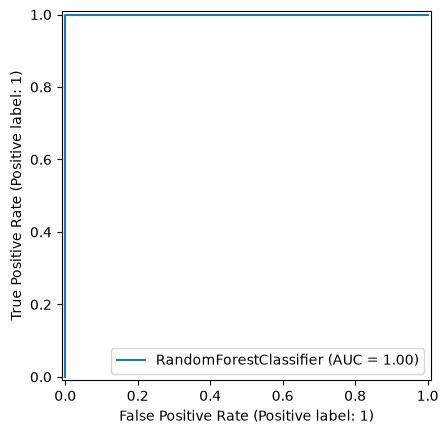

In [161]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    loaded_model,
    X_test,
    y_test
)

plt.show()

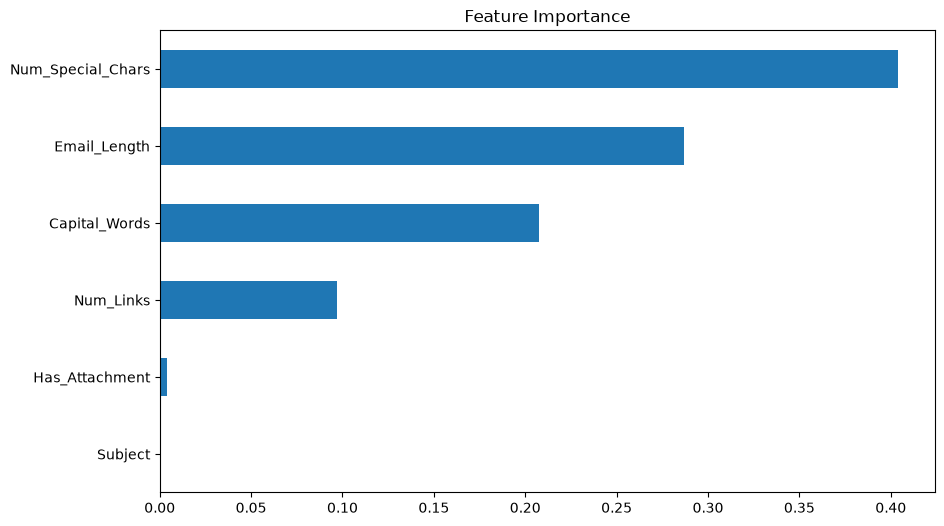

In [162]:
importance = pd.Series(
    loaded_model.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values()

plt.figure(figsize=(10,6))

importance.plot(kind="barh")

plt.title("Feature Importance")

plt.show()